**1. Import the libraries**

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [24]:
import matplotlib.pyplot as plt

colors = ['#2D5F4C','#5B8C77','#A8C3B5','#D4A574','#C97B63','#8B5A5A','#6B4C5A']

**2. Load the data**

In [3]:
file_path = "data/online_retail_II.xlsx"
retail_file = pd.ExcelFile(file_path)
print(retail_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [4]:
df_2009 = pd.read_excel(retail_file, sheet_name='Year 2009-2010')
df_2010 = pd.read_excel(retail_file, sheet_name='Year 2010-2011')

df = pd.concat([df_2009, df_2010], ignore_index=True)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


**3. Check proof of access**

In [5]:
print('Date range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())
print('Unique customers:', df['Customer ID'].nunique())
print('Missing Customer ID:', df['Customer ID'].isna().sum(),
      f"({df['Customer ID'].isna().mean()*100:.1f}%)")

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5942
Missing Customer ID: 243007 (22.8%)


**4. Clean the data**

In [6]:
# Create a copy of data
df_clean = df.copy()
# Drop rows with no Customer ID
df_clean = df.dropna(subset=['Customer ID'])

# Drop rows with non-positive quantity or price (returns, data errors, adjustments)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Drop cancellations — Invoice numbers starting with 'C' are cancelled orders
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]

# Create a line-item total
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Customer ID as integer (cause it loads as float because of the NaNs we just removed)
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print('Retained:', f"{len(df_clean)/len(df)*100:.1f}%")

Original rows: 1067371
Clean rows: 805549
Rows removed: 261822
Retained: 75.5%


**5. Set up the time-based split**

In [9]:
max_date = df_clean['InvoiceDate'].max()
cutoff_date = max_date - pd.Timedelta(days=90)

past = df_clean[df_clean['InvoiceDate'] <= cutoff_date].copy()
future = df_clean[df_clean['InvoiceDate'] > cutoff_date].copy()

print('Feature window ends:', cutoff_date)
print('Past transactions:', len(past), '| customers:', past['Customer ID'].nunique())
print('Future transactions:', len(future), '| customers:', future['Customer ID'].nunique())

Feature window ends: 2011-09-10 12:50:00
Past transactions: 644022 | customers: 5281
Future transactions: 161527 | customers: 2889


**6. RFM features from the PAST window only**

In [11]:
snapshot_date = past['InvoiceDate'].max()  # "today" as far as your features know

rfm = past.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   5281.000000  5281.000000  5281.000000    5281.000000
mean   15324.100170   206.690210     5.745692    2705.436178
std     1712.323865   175.017643    11.464582   12535.825033
min    12346.000000     0.000000     1.000000       2.900000
25%    13850.000000    49.000000     1.000000     323.860000
50%    15313.000000   163.000000     3.000000     804.020000
75%    16807.000000   326.000000     6.000000    2118.750000
max    18287.000000   647.000000   309.000000  484615.100000


**7. FUTURE window label** 

In [16]:
future_customers = set(future['Customer ID'].unique())
rfm['repeat_purchase'] = rfm['Customer ID'].isin(future_customers).astype(int)

print(rfm['repeat_purchase'].value_counts(normalize=True))

repeat_purchase
0    0.565991
1    0.434009
Name: proportion, dtype: float64


**8. Score RFM into quintiles**

In [15]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

**9. Build segment labels**

In [17]:
def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk (High Value)'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
Champions               1213
Loyal Customers         1181
Lost                    1086
Needs Attention          646
At Risk                  562
New Customers            381
At Risk (High Value)     212
Name: count, dtype: int64


**Chart 1: Customer count by segment**

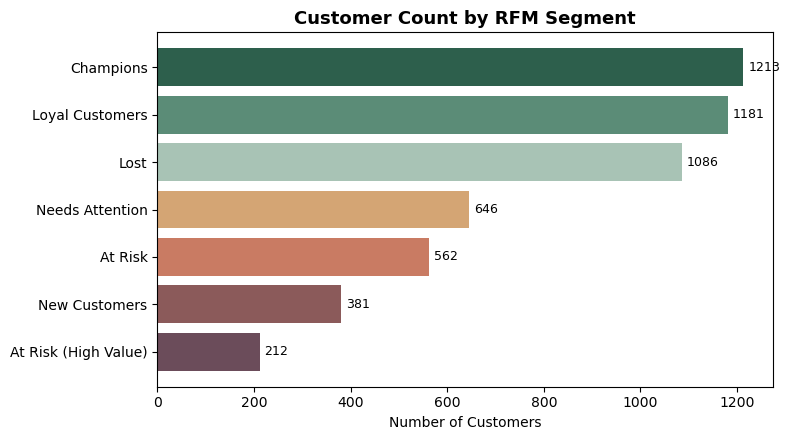

In [27]:
order = rfm['Segment'].value_counts().index
segment_counts = rfm['Segment'].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(segment_counts.index[::-1], segment_counts.values[::-1], 
                color=colors[:len(seg_counts)][::-1])
ax.set_xlabel('Number of Customers')
ax.set_title('Customer Count by RFM Segment', fontsize=13, fontweight='bold')

for bar, val in zip(bars, segment_counts.values[::-1]):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_segment_sizes.png', dpi=150)
plt.show()

**10. Sanity-check segments against the actual label**

In [18]:
print(rfm.groupby('Segment')['repeat_purchase'].mean().sort_values(ascending=False))
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False))

Segment
Champions               0.802143
Loyal Customers         0.504657
New Customers           0.477690
At Risk (High Value)    0.367925
At Risk                 0.290036
Needs Attention         0.244582
Lost                    0.130755
Name: repeat_purchase, dtype: float64
Segment
Champions               1.004286e+07
Loyal Customers         2.027170e+06
At Risk (High Value)    7.518096e+05
At Risk                 5.023654e+05
Needs Attention         5.001413e+05
Lost                    2.666182e+05
New Customers           1.964467e+05
Name: Monetary, dtype: float64


**Chart 2: Revenue share by segment**

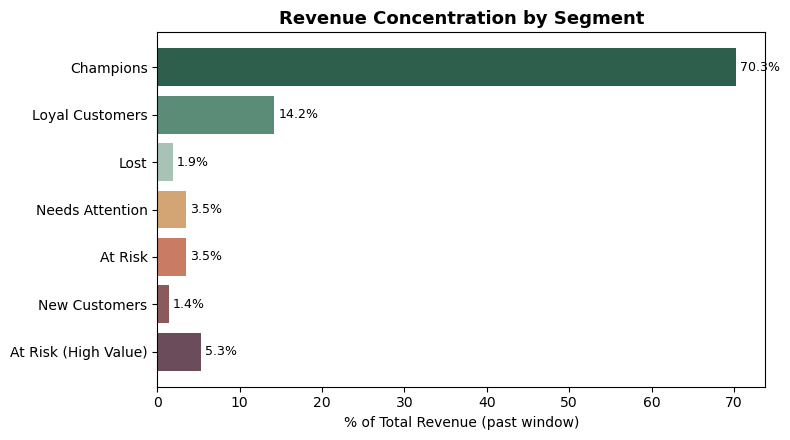

In [28]:
rev = rfm.groupby('Segment')['Monetary'].sum().reindex(order)
rev_pct = (rev / rev.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(rev_pct.index[::-1], rev_pct.values[::-1], 
                color=colors[:len(rev_pct)][::-1])
ax.set_xlabel('% of Total Revenue (past window)')
ax.set_title('Revenue Concentration by Segment', fontsize=13, fontweight='bold')

for bar, val in zip(bars, rev_pct.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_revenue_share.png', dpi=150)
plt.show()

**11. Train the logistic regression**

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, confusion_matrix

In [20]:
rfm['log_Frequency'] = np.log1p(rfm['Frequency'])
rfm['log_Monetary'] = np.log1p(rfm['Monetary'])

feature_cols = ['Recency', 'log_Frequency', 'log_Monetary']
X = rfm[feature_cols]
y = rfm['repeat_purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**12. Evaluate**

In [21]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

for name, coef in zip(feature_cols, model.coef_[0]):
    print(name, coef)

Accuracy: 0.7153671461014383
ROC AUC: 0.7913598566508946
Precision: 0.6807339449541284
Recall: 0.6474694589877836
[[574 174]
 [202 371]]
Recency -0.7681346348481449
log_Frequency 0.4212069045873246
log_Monetary 0.33560822074615704


**13. Naive baseline comparison**

In [23]:
naive_pred = (X_test['Recency'] <= rfm['Recency'].median()).astype(int)
print('Naive accuracy:', accuracy_score(y_test, naive_pred))

majority_pred = np.zeros(len(y_test))
print('Majority-class accuracy:', accuracy_score(y_test, majority_pred))

Naive accuracy: 0.6971990915972748
Majority-class accuracy: 0.5662376987130961
